In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl
from torch.distributions import Bernoulli
import xarray as xr
import xrft
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import pandas as pd
import functools as ft
from collections import namedtuple
from IPython.display import Markdown, display
from omegaconf import OmegaConf
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.colors as colors
from matplotlib.colors import LogNorm 
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from PIL import Image
import kornia.filters as kfilts
from torch.amp import autocast, GradScaler
from scipy.ndimage import gaussian_filter
from scipy.ndimage import binary_dilation
from skimage.morphology import disk, dilation
from sklearn.linear_model import LinearRegression

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#device = "cpu"

: 

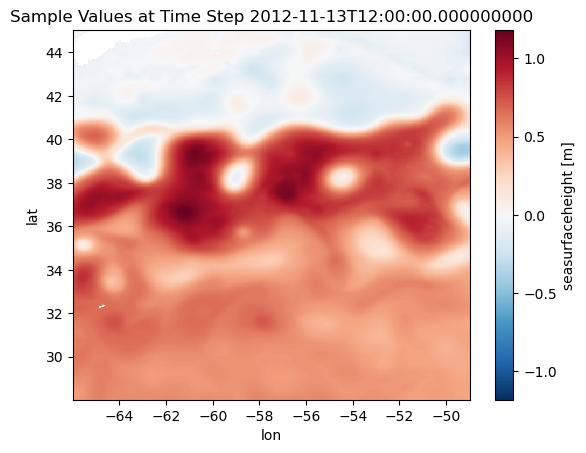

In [2]:
tgt_ds_ecs = xr.open_dataset('/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_cutoff_freq_regrid_0_1000m.nc')
tgt_ds = xr.open_dataset('/Odyssey/public/natl60/ssh/NATL60-CJM165-ssh-2012-2013-1_20.nc')
time_step_ssh = '2012-11-13T00:00:00.000000000'
time_step     = '2012-11-13T12:00:00.000000000' 
inp_da = tgt_ds.ssh.sel(time=time_step_ssh)
#inp_da = tgt_ds_ecs.ecs.sel(time=time_step)

# lat_shape = len(inp_da_dim.lat)
# lon_shape = len(inp_da_dim.lon)

# crop_lat_start =  20
# crop_lat_end = lat_shape -  20
# crop_lon_start =  20
# crop_lon_end = lon_shape -  20

inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

border_size = 30

lat_shape = len(inp_da_GS.lat)
lon_shape = len(inp_da_GS.lon)

crop_lat_start =  border_size
crop_lat_end = lat_shape -  border_size
crop_lon_start =  border_size
crop_lon_end = lon_shape -  border_size

inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

inp_da_GS.fillna(0.0)
lambda_value = 15.0
inp_da_GS.plot()
plt.title(f"Sample Values at Time Step {time_step}")
plt.show()

# Warped Field Perturbations

In [3]:
N = lat_shape  # Grid size
L = 5.0  # Spatial correlation length
T_corr = 1.0  # Temporal correlation length
sigma = 60  # Standard deviation of the field

def generate_correlated_fields(N, L, T_corr, sigma, num_fields=10, device=device,seed=41):
    """
    Generate a series of 2D fields with both spatial and temporal correlations.

    Parameters:
        N (int): Grid size (assumed to be square, NxN).
        L (float): Spatial correlation length.
        T_corr (float): Temporal correlation length.
        sigma (float): Standard deviation of the field.
        num_fields (int): Number of fields to generate (default is 10).
        device (str): Device to run the computations on ('cpu' or 'cuda').

    Returns:
        torch.Tensor: Generated fields of shape (num_fields, N, N).
    """
    torch.manual_seed(seed)
    # Define the time points for the fields
    time_points = torch.linspace(0, num_fields - 1, num_fields, device=device)
    # Compute the temporal covariance matrix
    C_temporal = torch.exp(-abs(time_points[:, None] - time_points[None, :]) / T_corr)
    # Perform Cholesky decomposition to get the temporal correlation factors
    L_chol = torch.linalg.cholesky(C_temporal)
    # Generate independent Gaussian white noise for each time point
    white_noises = torch.randn((num_fields, N, N), device=device)
    # Combine white noise using the Cholesky factors to induce temporal correlation
    temporal_correlated_noises = torch.matmul(L_chol, white_noises.view(num_fields, -1)).view(num_fields, N, N)
    # Generate 2D grid of wavenumbers for spatial correlation
    kx = torch.fft.fftfreq(N, device=device) * N
    ky = torch.fft.fftfreq(N, device=device) * N
    k = torch.sqrt(kx[:, None]**2 + ky[None, :]**2)
    cutoff_mask = (k < 20).float()  # High-frequency cutoff
    # apply - if we apply the same approach to vorticity, and then obtain 
    # stream function, 
    # Spatial covariance (Power spectrum) for Gaussian covariance
    P_k = torch.exp(-0.5 * (k * L)**3)
    P_k[0, 0] = 0.0
    P_k = P_k / torch.sum(P_k)
    # Generate fields using Fourier transform
    fields = []
    for i in range(num_fields):
        noise_ft = torch.fft.fft2(temporal_correlated_noises[i])
        field_ft = noise_ft * sigma**2 * torch.sqrt(P_k) * cutoff_mask
        field = torch.fft.ifft2(field_ft).real
        fields.append(field)
    return torch.stack(fields)

# Generate a Gaussian random field with a high-frequency cutoff
displacement_x = generate_correlated_fields(N, L, T_corr, sigma, device=device, seed=41)
displacement_y = generate_correlated_fields(N, L, T_corr, sigma, device=device, seed=41)
# fake_dx=torch.zeros_like(displacement_x)

# We now perturb the fields at the same way,
def warp_field(field, dx, dy):
    """
    Warp a 2D field based on displacement fields dx and dy.
    field (torch.Tensor): Input field of shape (batch_size, height, width)
    dx (torch.Tensor): X-displacement field of shape (batch_size, height, width)
    dy (torch.Tensor): Y-displacement field of shape (batch_size, height, width)
    """
    batch_size, _, height, width = field.shape
    
    # Create base grid
    y, x = torch.meshgrid(torch.arange(height), torch.arange(width), indexing='ij')
    base_grid = torch.stack((x, y), dim=-1).float()
    dx=dx.to(field.dtype)  # Adjust size as needed
    dy=dy.to(field.dtype) 
    # Add batch dimension and move to the same device as input field
    base_grid = base_grid.unsqueeze(0).repeat(batch_size,1,1,1).to(field.device)

    # Apply displacements
    sample_grid = base_grid + torch.stack((dx, dy), dim=-1)
    sample_grid[..., 0] = sample_grid[..., 0] % (width)
    sample_grid[..., 1] = sample_grid[..., 1] % (height)
    

    # Normalize grid to [-1, 1] range
    sample_grid[..., 0] = 2 * sample_grid[..., 0] / (width) - 1
    sample_grid[..., 1] = 2 * sample_grid[..., 1] / (height) - 1

    # Perform sampling
    warped_field = F.grid_sample(field, sample_grid, mode='bilinear', padding_mode='reflection', align_corners=False)
    return warped_field,torch.max(sample_grid), torch.min(sample_grid)


batch_size = 10
channels = 1

# Prepare data
mean_tgt = inp_da_GS.mean().item()
std_tgt = inp_da_GS.std().item()

tens_inp = torch.from_numpy(inp_da_GS.values).nan_to_num().float().to(device)
tens_inp = (tens_inp - mean_tgt) / std_tgt
tens_inp.unsqueeze_(0)
print(tens_inp.shape)
tens_inp = tens_inp.repeat(batch_size, 1, 1, 1)
# Create a sample field (e.g., a gradient)
field = tens_inp
displacement_x = displacement_x 
displacement_y = displacement_y
mean_x=torch.tensor(0.0)
mean_y=torch.tensor(0.0)
#mean_x=torch.tensor(6.0)
#mean_y=torch.tensor(5.0)

# Perform warping
warped_field,max_grid,min_grid = warp_field(field, displacement_x+mean_x, displacement_y+mean_y)

print(f"Input field shape: {field.shape}")
print(f"Warped field shape: {warped_field.shape}")

# Function to create a 2D Gaussian kernel
def gaussian_kernel(kernel_size=5, sigma=1.0, dtype=torch.float32, device='cuda'):
    # Create a 2D grid of coordinates (x, y)
    x = torch.arange(kernel_size, dtype=dtype, device=device) - (kernel_size - 1) / 2
    y = torch.arange(kernel_size, dtype=dtype, device=device) - (kernel_size - 1) / 2
    xx, yy = torch.meshgrid(x, y)

    # Compute the Gaussian function on the grid
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    # Normalize the kernel to ensure the sum of the weights is 1
    kernel = kernel / kernel.sum()
    return kernel

# Function to apply Gaussian smoothing to a batch of images
def apply_gaussian_smoothing(input_tensor, kernel_size=15, sigma=1.0):
    dtype = input_tensor.dtype
    device = input_tensor.device
    kernel = gaussian_kernel(kernel_size, sigma, dtype=dtype, device=device)
    
    # Reshape the kernel to be [1, 1, kernel_size, kernel_size] (for 2D convolution)
    kernel = kernel.view(1, 1, kernel_size, kernel_size)

    # Expand the kernel to apply it across all channels and the batch
    kernel = kernel.expand(1, 1, kernel_size, kernel_size)

    padding=kernel_size//2
    # Pad the input tensor with circular padding
    padded_input = F.pad(input_tensor, (padding, padding, padding, padding), mode='reflect')

    # Apply the convolution (use groups=batch_size to apply the kernel individually per batch element)
    smoothed_tensor = F.conv2d(padded_input, kernel, groups=1)

    # Remove the extra channel dimension
    return smoothed_tensor 


# Smmothing
smoothed_tensor=apply_gaussian_smoothing(warped_field,kernel_size=10,sigma=1.5)

torch.Size([1, 340, 340])
Input field shape: torch.Size([10, 1, 340, 340])
Warped field shape: torch.Size([10, 1, 340, 340])


/Odyssey/private/ochapron/miniconda/miniconda3/envs/fdv/lib/python3.10/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789115564/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [4]:
warped_field_squeezed = warped_field.squeeze(1)
print(warped_field_squeezed.shape)
warped_field_squeezed_np = warped_field_squeezed.cpu().detach().numpy()
warped_field_squeezed_np.shape 
warped_field_np = warped_field_squeezed_np[:,border_size:-border_size,border_size:-border_size]
warped_field_np.shape

torch.Size([10, 340, 340])


(10, 280, 280)

In [5]:
# import numpy as np
# from scipy.linalg import qr

# def pivoted_qr_sampling(ensemble_data, n_points_rate):
#     """
#     ensemble_data: numpy array of shape (n_ens, Nx, Ny).
#     n_points: number of grid points to select.

#     Returns
#     -------
#     selected_points : list of (x, y) indices
#     """

#     n_ens, Nx, Ny = ensemble_data.shape
#     # Flatten each (Nx, Ny) field into 1D of size Nx*Ny
#     # We'll form a data matrix D of shape (n_ens, Nx*Ny)
#     D = ensemble_data.reshape(n_ens, Nx*Ny)
#     n_points = int(n_points_rate*Nx*Ny)
#     print(f"Number of points to select: {n_points}")
#     # Optional: center or scale the data if desired
#     mean_field = np.mean(D, axis=0, keepdims=True)
#     D_centered = D - mean_field

#     # We do a pivoted QR on the transpose so that we're pivoting over columns = grid points
#     # D_centered^T shape = (Nx*Ny, n_ens)
#     # Q, R, piv = pivoted QR of shape = (Nx*Ny, n_ens)
#     Q, R, piv = qr(D_centered.T, pivoting=True)

#     # 'piv' is the permutation array describing how columns (grid points) are ordered by importance
#     # First 'n_points' entries in 'piv' give the top columns
#     chosen_indices = piv[:n_points]
#     print(piv)
#     # Convert linear index back to (x, y)
#     selected_points = [(idx // Ny, idx % Ny) for idx in chosen_indices]
#     return selected_points

# # Example usage:
# if __name__ == "__main__":
#     selected_pts_qr = pivoted_qr_sampling(warped_field_np, n_points_rate=0.001)
#     print("Pivoted QR - Selected grid points (x, y):", selected_pts_qr)
#     print("Number of selected grid points:", len(selected_pts_qr))

In [6]:
def pca_svd_sampling(ensemble_data, r=5, n_points_rate=50):
    """
    ensemble_data: numpy array of shape (n_ens, Nx, Ny).
    r: number of principal components to consider.
    n_points: total number of grid points to select.

    Returns
    -------
    selected_points : list of (x, y) indices of the selected grid points.
    """
    n_ens, Nx, Ny = ensemble_data.shape
    # Flatten each (Nx, Ny) field into 1D of size Nx*Ny
    D = ensemble_data.reshape(n_ens, Nx * Ny)  # shape (n_ens, Nx*Ny)
    n_points = int(n_points_rate*Nx*Ny)

    # Optional: center the data by subtracting the mean across the ensemble
    mean_field = np.mean(D, axis=0, keepdims=True)
    D_centered = D - mean_field

    # Compute SVD on the centered data
    # D_centered = U (S) V^T  --> we want V^T or V for the spatial patterns
    U, S, Vt = np.linalg.svd(D_centered, full_matrices=False)

    # Vt.shape = (n_ens, Nx*Ny)
    # The columns of V (rows of Vt) are the principal components in "space"
    # We'll focus on the top r principal components
    Vtop = Vt[:r, :]  # shape (r, Nx*Ny)

    # Find the locations with largest absolute coefficient in these r components
    # We can sum up absolute values across the r components
    abs_sum = np.sum(np.abs(Vtop), axis=0)  # shape (Nx*Ny,)

    # Now pick the top n_points
    idx_sorted = np.argsort(abs_sum)[::-1]      # descending order
    chosen_indices = idx_sorted[:n_points]

    # Convert linear index back to (x, y)
    selected_points = [(idx // Ny, idx % Ny) for idx in chosen_indices]
    return selected_points


# Example usage:
if __name__ == "__main__":
    # Perform PCA-based sampling
    selected_pts = pca_svd_sampling(warped_field_np, r=5, n_points_rate=0.001)
    print("Selected grid points (x, y):", selected_pts)
    print("Number of selected grid points:", len(selected_pts))

Selected grid points (x, y): [(174, 25), (175, 24), (174, 24), (175, 25), (174, 26), (175, 23), (173, 25), (173, 26), (176, 24), (176, 23), (175, 26), (174, 23), (177, 23), (178, 22), (173, 24), (177, 22), (174, 27), (176, 25), (173, 27), (178, 21), (176, 22), (179, 21), (178, 23), (177, 24), (175, 22), (179, 22), (179, 20), (177, 21), (178, 20), (180, 20), (180, 21), (179, 23), (175, 27), (176, 26), (180, 19), (178, 24), (173, 23), (174, 22), (180, 22), (172, 26), (177, 25), (173, 28), (181, 20), (179, 19), (176, 21), (174, 28), (172, 25), (181, 21), (172, 27), (181, 19), (180, 23), (177, 20), (182, 19), (179, 24), (182, 20), (181, 22), (175, 21), (181, 18), (182, 18), (182, 21), (183, 19), (184, 20), (178, 19), (180, 18), (183, 22), (183, 21), (172, 24), (183, 20), (184, 21), (183, 18), (184, 19), (178, 25), (182, 22), (184, 18), (181, 23), (182, 23), (176, 27), (175, 28)]
Number of selected grid points: 78


In [ ]:
def stratified_block_sampling(Nx, Ny, n_blocks_x, n_blocks_y, seed=0):
    """
    Partition the Nx x Ny grid into n_blocks_x x n_blocks_y blocks.
    Randomly select one point from each block.
    """
    np.random.seed(seed)
    block_size_x = Nx // n_blocks_x
    block_size_y = Ny // n_blocks_y
    
    coords = []
    for bx in range(n_blocks_x):
        for by in range(n_blocks_y):
            # Define the block boundaries
            x_start = bx * block_size_x
            x_end   = min((bx + 1) * block_size_x, Nx)
            y_start = by * block_size_y
            y_end   = min((by + 1) * block_size_y, Ny)
            # Randomly pick a point within this block
            x_rand = np.random.randint(x_start, x_end)
            y_rand = np.random.randint(y_start, y_end)
            coords.append((x_rand, y_rand))
    return coords


# Nx, Ny = 50, 50
# coords_stratified = stratified_block_sampling(Nx, Ny, 5, 5)

Nx, Ny = 280, 280
n_blocks = 78
n_blocks_x = int(np.sqrt(n_blocks))
n_blocks_y = int(np.sqrt(n_blocks))
coords_stratified = stratified_block_sampling(Nx, Ny, n_blocks_x, n_blocks_y)
print(coords_stratified)
mask = torch.zeros((Nx, Ny), device=device)
for x, y in coords_stratified:
    mask[x, y] = 1
print(mask)


[(0, 3), (3, 44), (19, 91), (23, 111), (24, 164), (12, 176), (23, 234), (17, 270), (48, 8), (44, 55), (51, 75), (50, 105), (53, 164), (64, 194), (54, 224), (67, 246), (79, 32), (101, 45), (93, 81), (98, 139), (70, 140), (75, 192), (85, 214), (101, 246), (106, 11), (123, 62), (105, 84), (117, 125), (116, 144), (111, 179), (108, 222), (119, 260), (160, 23), (155, 48), (161, 75), (140, 136), (145, 170), (140, 209), (169, 213), (174, 258), (196, 9), (175, 45), (198, 72), (209, 135), (178, 158), (195, 192), (202, 224), (176, 255), (232, 11), (212, 51), (242, 70), (229, 118), (240, 164), (212, 178), (240, 244), (223, 253), (264, 31), (253, 61), (247, 73), (259, 137), (249, 143), (256, 197), (258, 221), (261, 269)]
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')


In [8]:
def optimal_interpolation(data_with_nans, length_scale=15., sigma_f=1.0, sigma_n=0.1):
    """
    Perform optimal interpolation (kriging) on a 2D tensor with missing data (NaNs).

    Parameters:
    - data_with_nans (torch.Tensor): 2D tensor with missing values represented as NaN.
    - length_scale (float or torch.Tensor): Length scale parameter for the RBF kernel.
    - sigma_f (float or torch.Tensor): Signal variance parameter for the RBF kernel.
    - sigma_n (float or torch.Tensor): Noise variance parameter.

    Returns:
    - reconstructed_data (torch.Tensor): 2D tensor with missing values reconstructed.
    """
    device = data_with_nans.device
    H, W = data_with_nans.shape

    observed_indices = ~torch.isnan(data_with_nans)
    observed_positions = torch.nonzero(observed_indices, as_tuple=False).float()  # Positions (i, j)
    observed_values = data_with_nans[observed_indices].to(device)

    missing_indices = torch.isnan(data_with_nans)
    missing_positions = torch.nonzero(missing_indices, as_tuple=False).float()

    observed_positions_x = observed_positions[:, 1] #/ (W - 1) * 10  
    observed_positions_y = observed_positions[:, 0] #/ (H - 1) * 10  
    observed_coords = torch.stack([observed_positions_x, observed_positions_y], dim=1)

    missing_positions_x = missing_positions[:, 1] #/ (W - 1) * 10
    missing_positions_y = missing_positions[:, 0] #/ (H - 1) * 10
    missing_coords = torch.stack([missing_positions_x, missing_positions_y], dim=1)

    # Define the covariance function (RBF kernel)
    def cov_func(x1, x2, length_scale, sigma_f):
        """
        Compute the covariance matrix using the RBF kernel.
        """
        x1 = x1.unsqueeze(1)  # Shape: [N1, 1, 2]
        x2 = x2.unsqueeze(0)  # Shape: [1, N2, 2]
        sqdist = ((x1 - x2) ** 2).sum(dim=2)  # Shape: [N1, N2]
        return sigma_f ** 2 * torch.exp(-0.5 / length_scale ** 2 * sqdist)

    # Ensure hyperparameters are tensors on the correct device
    if not isinstance(length_scale, torch.Tensor):
        length_scale = torch.tensor(length_scale, device=device)
    if not isinstance(sigma_f, torch.Tensor):
        sigma_f = torch.tensor(sigma_f, device=device)
    if not isinstance(sigma_n, torch.Tensor):
        sigma_n = torch.tensor(sigma_n, device=device)

    # Compute covariance matrices
    K = cov_func(observed_coords, observed_coords, length_scale, sigma_f)
    K += sigma_n ** 2 * torch.eye(K.size(0), device=device)  # Add noise variance
    K_s = cov_func(observed_coords, missing_coords, length_scale, sigma_f)

    # Cholesky decomposition
    L = torch.cholesky(K + 1e-6 * torch.eye(K.size(0), device=device))  # Add jitter for numerical stability

    # Solve for alpha
    alpha = torch.cholesky_solve(observed_values.unsqueeze(1), L)

    # Predict mean at missing points
    mean_pred = K_s.t().matmul(alpha).squeeze()
    mean_pred = mean_pred.to(torch.float32)

    # Reconstruct the data tensor
    reconstructed_data = data_with_nans.clone()
    reconstructed_data[missing_indices] = mean_pred

    return reconstructed_data

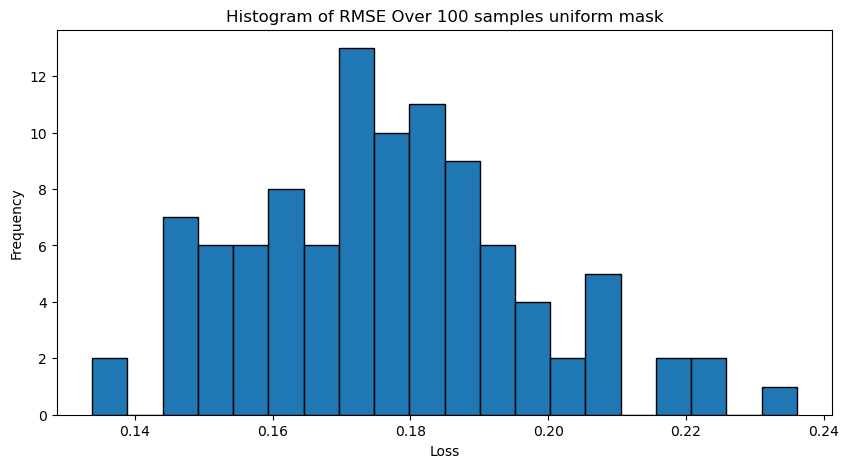

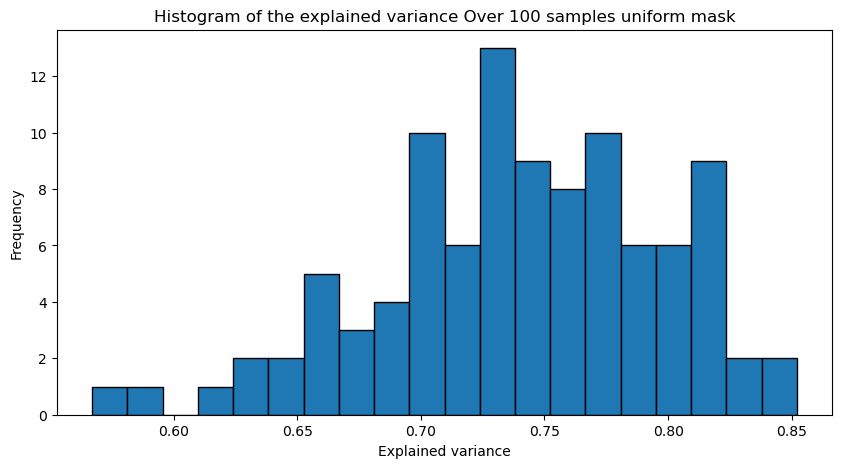

Mean Loss untrained: 0.1767185628414154
Normalized Selected Points: 0.0011989795602858067


In [ ]:
tau = 1
lat_shape = len(inp_da_GS.lat)
lon_shape = len(inp_da_GS.lon)

crop_lat_start =  border_size
crop_lat_end = lat_shape -  border_size
crop_lon_start =  border_size
crop_lon_end = lon_shape -  border_size

inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

border_size = 30
hard = True 
padding_size = 10  # Adjust this value as needed

mean_tgt = inp_da_GS_crop.mean().item()
std_tgt = inp_da_GS_crop.std().item()

tens_inp_da = torch.from_numpy(inp_da_GS_crop.values).float().to(device)
tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da.requires_grad_(True)
time= 1
lat, lon =  inp_da_GS_crop.shape
tgt_inp = tens_inp_da.clone()
rate = 0.999
losses_init = []
exp_var_init = []
logits_inits_init = torch.zeros((2,1,lat,lon)).to(device)
logits_inits_init[1, :, :, :] = np.log(rate / (1 - rate))

for _ in range(100):
    gs_output = F.gumbel_softmax(logits_inits_init, hard=True, dim=0)[0, :, :, :]
    mask_input = gs_output.view(time,lat, lon)
    mask_input = mask_input.unsqueeze(0)  # Add batch dimension if necessary
    mask = mask_input
    selected_tgt_inp = tgt_inp * mask
    selected_tgt_inp[mask == 0] = float('nan')
    # Perform optimal interpolation
    output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=25.0)

    # Plot the output tensor
    output_numpy = output.detach().cpu().numpy()
    tgt_center_numpy = tgt_inp.detach().cpu().numpy()

    output_numpy_non = (output_numpy * std_tgt) + mean_tgt
    tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

    rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

    #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
    losses_init.append(rmse_loss)

    # Calculate variance of residuals and actual values
    residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
    actual_variance = np.var(tgt_center_non, ddof=1)

    # Explained Variance
    explained_variance = 1 - (residual_variance / actual_variance)
    exp_var_init.append(explained_variance)

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(losses_init, bins=20, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples uniform mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(exp_var_init, bins=20, edgecolor='black')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples uniform mask')
plt.show()

# Print the mean of the losses
mean_loss_value_init = np.mean(losses_init)
print(f"Mean Loss untrained: {mean_loss_value_init}")

gs_output = F.gumbel_softmax(logits_inits_init, tau=tau, hard=hard, dim=0)[0, :, :, :]
mask_input = gs_output.view(time,lat, lon)
mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
normalized_selected_points = mask_input.mean()

valid_points_mask = ~torch.isnan(selected_tgt_inp)
print(f"Normalized Selected Points: {normalized_selected_points}")

In [9]:
tau = 1
lat_shape = len(inp_da_GS.lat)
lon_shape = len(inp_da_GS.lon)

crop_lat_start =  border_size
crop_lat_end = lat_shape -  border_size
crop_lon_start =  border_size
crop_lon_end = lon_shape -  border_size

inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

border_size = 30
hard = True 
padding_size = 10  # Adjust this value as needed

mean_tgt = inp_da_GS_crop.mean().item()
std_tgt = inp_da_GS_crop.std().item()

tgt_inp = torch.from_numpy(inp_da_GS_crop.values).float().to(device)
tgt_inp = (tgt_inp - mean_tgt) / std_tgt

tgt_inp.requires_grad_(True)
time= 1
lat, lon =  inp_da_GS_crop.shape
rate = 0.999
losses_init = []
exp_var_init = []

Nx, Ny = lat, lon
n_blocks = rate*Nx*Ny
n_blocks_x = int(np.sqrt(n_blocks))
n_blocks_y = int(np.sqrt(n_blocks))
for _ in range(100):
    coords_stratified = stratified_block_sampling(Nx, Ny, n_blocks_x, n_blocks_y)
    mask = torch.zeros((Nx, Ny))
    for x, y in coords_stratified:
        mask[x, y] = 1
    mask = mask.to(device)
    print(mask.shape)
    print(tgt_inp.shape)
    selected_tgt_inp = tgt_inp * mask
    selected_tgt_inp[mask == 0] = float('nan')
    del mask

    # Perform optimal interpolation
    output = optimal_interpolation(selected_tgt_inp, length_scale=25.0)
    # Plot the output tensor
    output_numpy = output.detach().cpu().numpy()
    tgt_center_numpy = tgt_inp.detach().cpu().numpy()

    output_numpy_non = (output_numpy * std_tgt) + mean_tgt
    tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

    rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

    #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
    losses_init.append(rmse_loss)

    # Calculate variance of residuals and actual values
    residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
    actual_variance = np.var(tgt_center_non, ddof=1)

    # Explained Variance
    explained_variance = 1 - (residual_variance / actual_variance)
    exp_var_init.append(explained_variance)

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(losses_init, bins=20, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples uniform mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(exp_var_init, bins=20, edgecolor='black')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples uniform mask')
plt.show()

# Print the mean of the losses
mean_loss_value_init = np.mean(losses_init)
print(f"Mean Loss untrained: {mean_loss_value_init}")


torch.Size([280, 280])
torch.Size([280, 280])


OutOfMemoryError: CUDA out of memory. Tried to allocate 45.15 GiB. GPU 0 has a total capacity of 79.14 GiB of which 33.38 GiB is free. Including non-PyTorch memory, this process has 45.73 GiB memory in use. Of the allocated memory 45.18 GiB is allocated by PyTorch, and 32.99 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)